In [7]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import librosa
import os
import glob
import matplotlib.pyplot as plt
import soundfile as sf
from tqdm import tqdm
import random
import scipy.signal

# Keep the original configuration parameters
LATENT_DIM = 100
SR = 16000  # Sample rate from MIMII dataset
AUDIO_LENGTH = 10  # seconds (MIMII contains 10s segments)
N_FFT = 1024
HOP_LENGTH = 512
N_MELS = 128
BATCH_SIZE = 8  # Reduced batch size
EPOCHS = 2000
TIME_DIM = 313  # Setting this explicitly based on your output

# Improved version of the original function, keeping the same name and signature
def load_and_preprocess_audio(file_path, is_abnormal=False):
    """Load audio file and convert to mel spectrogram - improved version"""
    # Load audio file
    audio, _ = librosa.load(file_path, sr=SR, duration=AUDIO_LENGTH)
    
    # Normalize audio to prevent clipping
    audio = audio / (np.max(np.abs(audio)) + 1e-8)
    
    # Apply pre-emphasis to enhance high frequencies (common in speech/audio)
    audio = librosa.effects.preemphasis(audio)
    
    # Pad if needed
    if len(audio) < SR * AUDIO_LENGTH:
        audio = np.pad(audio, (0, SR * AUDIO_LENGTH - len(audio)))
    elif len(audio) > SR * AUDIO_LENGTH:
        audio = audio[:SR * AUDIO_LENGTH]
    
    # Create mel spectrogram with improved parameters
    mel_spec = librosa.feature.melspectrogram(
        y=audio, 
        sr=SR, 
        n_fft=N_FFT, 
        hop_length=HOP_LENGTH, 
        n_mels=N_MELS,
        fmin=20,  # Explicitly set frequency range
        fmax=SR//2-1000  # Avoid highest frequencies which can be noisy
    )
    
    # Convert to log scale
    log_mel_spec = librosa.power_to_db(mel_spec)
    
    # Better normalization: normalize to [-1, 1] range instead of [0, 1]
    # This helps the model learn the distribution better
    log_mel_spec_min = log_mel_spec.min()
    log_mel_spec_max = log_mel_spec.max()
    log_mel_spec_norm = 2 * (log_mel_spec - log_mel_spec_min) / (log_mel_spec_max - log_mel_spec_min) - 1
    
    # Add channel dimension
    log_mel_spec_norm = np.expand_dims(log_mel_spec_norm, axis=-1)
    
    # Pad to match expected shape if needed
    if log_mel_spec_norm.shape[1] < TIME_DIM:
        pad_width = ((0, 0), (0, TIME_DIM - log_mel_spec_norm.shape[1]), (0, 0))
        log_mel_spec_norm = np.pad(log_mel_spec_norm, pad_width, mode='constant')
    elif log_mel_spec_norm.shape[1] > TIME_DIM:
        log_mel_spec_norm = log_mel_spec_norm[:, :TIME_DIM, :]
    
    # Add label for condition (0 for normal, 1 for abnormal)
    condition = 1 if is_abnormal else 0
    
    return log_mel_spec_norm, condition

# Keep the existing process_mimii_dataset function as is
def process_mimii_dataset(base_dir, machine_type, machine_ids=["00", "02", "04", "06"], samples_per_id=50):
    """Process MIMII dataset files for a specific machine type"""
    specs = []
    conditions = []
    
    print(f"\nProcessing {machine_type} data...")
    machine_dir = os.path.join(base_dir, f"trimmed_{machine_type}")
    
    if not os.path.exists(machine_dir):
        print(f"Error: Directory not found: {machine_dir}")
        return np.array([]), np.array([])
        
    # Process normal samples
    normal_base_dir = os.path.join(machine_dir, "normal")
    if os.path.exists(normal_base_dir):
        # Process each machine ID
        for machine_id in machine_ids:
            normal_id_dir = os.path.join(normal_base_dir, f"id_{machine_id}")
            if os.path.exists(normal_id_dir):
                normal_files = glob.glob(os.path.join(normal_id_dir, "*.wav"))
                
                print(f"Processing {len(normal_files)} normal files for {machine_type} id_{machine_id}")
                # Limit to samples_per_id files per ID for faster processing
                for file_path in tqdm(normal_files[:samples_per_id]):
                    try:
                        spec, condition = load_and_preprocess_audio(file_path, is_abnormal=False)
                        specs.append(spec)
                        conditions.append(condition)
                    except Exception as e:
                        print(f"Error processing {file_path}: {e}")
            else:
                print(f"Directory not found: {normal_id_dir}")
    else:
        print(f"Normal directory not found: {normal_base_dir}")
        
    # Process abnormal samples
    abnormal_base_dir = os.path.join(machine_dir, "abnormal")
    if os.path.exists(abnormal_base_dir):
        # Process each machine ID
        for machine_id in machine_ids:
            abnormal_id_dir = os.path.join(abnormal_base_dir, f"id_{machine_id}")
            if os.path.exists(abnormal_id_dir):
                abnormal_files = glob.glob(os.path.join(abnormal_id_dir, "*.wav"))
                
                print(f"Processing {len(abnormal_files)} abnormal files for {machine_type} id_{machine_id}")
                # Limit to samples_per_id files per ID for faster processing
                for file_path in tqdm(abnormal_files[:samples_per_id]):
                    try:
                        spec, condition = load_and_preprocess_audio(file_path, is_abnormal=True)
                        specs.append(spec)
                        conditions.append(condition)
                    except Exception as e:
                        print(f"Error processing {file_path}: {e}")
            else:
                print(f"Directory not found: {abnormal_id_dir}")
    else:
        print(f"Abnormal directory not found: {abnormal_base_dir}")
    
    # If no files were found, create some dummy data to avoid errors
    if len(specs) == 0:
        print("WARNING: No files were processed. Creating dummy data for debugging.")
        return np.zeros((10, N_MELS, TIME_DIM, 1)), np.zeros(10)
    
    # Convert to numpy arrays
    specs = np.array(specs)
    conditions = np.array(conditions)
    
    print(f"Dataset shape: {specs.shape}, Conditions shape: {conditions.shape}")
    print(f"Normal samples: {np.sum(conditions == 0)}, Abnormal samples: {np.sum(conditions == 1)}")
    
    return specs, conditions

# Keep the ExactOutputSize class unchanged
class ExactOutputSize(layers.Layer):
    def __init__(self, target_height, target_width, **kwargs):
        super(ExactOutputSize, self).__init__(**kwargs)
        self.target_height = target_height
        self.target_width = target_width
        
    def build(self, input_shape):
        super(ExactOutputSize, self).build(input_shape)
        
    def call(self, inputs):
        return tf.image.resize(inputs, [self.target_height, self.target_width])
    
    def compute_output_shape(self, input_shape):
        return (input_shape[0], self.target_height, self.target_width, input_shape[3])
        
    def get_config(self):
        config = super(ExactOutputSize, self).get_config()
        config.update({
            'target_height': self.target_height,
            'target_width': self.target_width
        })
        return config

# Create a proper Keras Layer for self-attention instead of a function
class SelfAttention(layers.Layer):
    def __init__(self, **kwargs):
        super(SelfAttention, self).__init__(**kwargs)
        self.gamma = tf.Variable(0.0, trainable=True)
        
    def build(self, input_shape):
        channels = input_shape[-1]
        self.query_conv = layers.Conv2D(channels // 8, 1, padding='same')
        self.key_conv = layers.Conv2D(channels // 8, 1, padding='same')
        self.value_conv = layers.Conv2D(channels, 1, padding='same')
        super(SelfAttention, self).build(input_shape)
        
    def call(self, x):
        batch_size, height, width, channels = tf.shape(x)[0], tf.shape(x)[1], tf.shape(x)[2], tf.shape(x)[3]
        
        # Apply convolutions to get query, key, value
        query = self.query_conv(x)
        key = self.key_conv(x)
        value = self.value_conv(x)
        
        # Reshape for matrix multiplication
        query_reshaped = tf.reshape(query, [-1, height * width, channels // 8])
        key_reshaped = tf.reshape(key, [-1, height * width, channels // 8])
        value_reshaped = tf.reshape(value, [-1, height * width, channels])
        
        # Calculate attention scores
        scores = tf.matmul(query_reshaped, tf.transpose(key_reshaped, [0, 2, 1]))
        attention_weights = tf.nn.softmax(scores, axis=-1)
        
        # Apply attention
        output = tf.matmul(attention_weights, value_reshaped)
        output = tf.reshape(output, [-1, height, width, channels])
        
        # Add residual connection with learnable parameter
        return x + self.gamma * output

# Modified build_generator function with Keras-compatible self-attention
def build_generator(latent_dim):
    """Build improved generator network with conditional input"""
    # Input for latent space
    noise = layers.Input(shape=(latent_dim,), name="noise_input")
    
    # Input for conditions (normal/abnormal)
    condition = layers.Input(shape=(1,), name="condition_input")
    
    # Embed the condition with higher dimension
    condition_embedding = layers.Embedding(2, 64)(condition)
    condition_embedding = layers.Flatten()(condition_embedding)
    
    # Concatenate noise and condition
    combined_input = layers.Concatenate()([noise, condition_embedding])
    
    # Dense layers with normalization and better activation
    x = layers.Dense(256)(combined_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    
    x = layers.Dense(512)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    
    # Calculate dimensions for reshaping
    target_height = N_MELS // 8  # 16
    target_width = TIME_DIM // 16  # ~19 for TIME_DIM=313
    
    x = layers.Dense(target_height * target_width * 64)(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Reshape((target_height, target_width, 64))(x)
    
    # First transposed convolution with residual path
    residual = x
    x = layers.Conv2DTranspose(64, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    
    # Second transposed convolution
    x = layers.Conv2DTranspose(32, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    # Add self-attention after this layer - now using proper Keras layer
    x = SelfAttention()(x)
    
    # Third transposed convolution
    x = layers.Conv2DTranspose(16, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    
    # Fourth transposed convolution
    x = layers.Conv2DTranspose(8, (4, 4), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    
    # Ensure exact output dimensions match the input data
    x = ExactOutputSize(N_MELS, TIME_DIM)(x)
    
    # Output layer with tanh activation for better output range
    output = layers.Conv2D(1, (3, 3), activation='tanh', padding='same')(x)
    
    # Model
    model = models.Model([noise, condition], output, name="generator")
    
    return model

# Modified build_discriminator function to use Keras-compatible attention
def build_discriminator():
    """Build improved discriminator network with conditional input"""
    # Input for spectrogram with explicit shape
    input_spec = layers.Input(shape=(N_MELS, TIME_DIM, 1), name="spec_input")
    
    # Input for conditions (normal/abnormal)
    condition = layers.Input(shape=(1,), name="condition_input")
    
    # Embedding layer for condition - reshape to match input spec dimensions
    embedding_dim = N_MELS * TIME_DIM
    condition_embedding = layers.Embedding(2, embedding_dim)(condition)
    condition_embedding = layers.Reshape((N_MELS, TIME_DIM, 1))(condition_embedding)
    
    # Concatenate inputs along the channel dimension
    combined_input = layers.Concatenate(axis=-1)([input_spec, condition_embedding])
    
    # Improved convolutional layers with additional dropout for stability
    x = layers.Conv2D(32, (5, 5), strides=(2, 2), padding='same')(combined_input)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    x = layers.Conv2D(256, (5, 5), strides=(2, 2), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    # Add attention using proper Keras Layer
    x = SelfAttention()(x)
    
    # Flatten and dense layers
    x = layers.Flatten()(x)
    x = layers.Dense(512)(x)
    x = layers.LeakyReLU(negative_slope=0.2)(x)
    x = layers.Dropout(0.3)(x)
    
    # Output layer
    output = layers.Dense(1, activation='sigmoid')(x)
    
    # Model
    model = models.Model([input_spec, condition], output, name="discriminator")
    
    return model

# Keeping the original GAN model function
def build_gan(generator, discriminator):
    """Build combined GAN model"""
    # Freeze discriminator during generator training
    discriminator.trainable = False
    
    # GAN input
    noise = layers.Input(shape=(LATENT_DIM,), name="gan_noise_input")
    condition = layers.Input(shape=(1,), name="gan_condition_input")
    
    # Generator output
    generated_spec = generator([noise, condition])
    
    # Discriminator output
    validity = discriminator([generated_spec, condition])
    
    # Combined model
    model = models.Model([noise, condition], validity, name="gan")
    
    return model

# Improved spectrogram to audio function with the original name
def spectrogram_to_audio(spectrogram):
    """Convert a generated spectrogram back to audio with improved quality"""
    # Remove extra dimensions
    spectrogram = spectrogram.squeeze()
    
    # Convert from normalized range back to appropriate dB range
    # If using tanh activation, the range is [-1, 1], so we adjust accordingly
    if np.min(spectrogram) < 0:  # Checking if we have negative values (tanh output)
        # Map from [-1, 1] to typical dB range for mel spectrograms [-80, 0]
        db_spectrogram = spectrogram * 40  # Scale the range to [-40, 40]
    else:
        # For sigmoid output [0, 1], map to [-80, 0]
        db_spectrogram = spectrogram * 80 - 80
    
    # Convert from dB back to power
    S = librosa.db_to_power(db_spectrogram)
    
    # Use Griffin-Lim algorithm with more iterations for better phase reconstruction
    y = librosa.feature.inverse.mel_to_audio(
        S, 
        sr=SR, 
        n_fft=N_FFT, 
        hop_length=HOP_LENGTH,
        power=2.0,
        n_iter=32  # More iterations for better quality
    )
    
    # Apply some post-processing for better audio quality
    
    # 1. Normalize
    y = y / (np.max(np.abs(y)) + 1e-8) * 0.9
    
    # 2. Apply a gentle high-pass filter to remove unwanted low frequencies
    def butter_highpass(cutoff, fs, order=5):
        nyq = 0.5 * fs
        normal_cutoff = cutoff / nyq
        b, a = scipy.signal.butter(order, normal_cutoff, btype='high', analog=False)
        return b, a
    
    def highpass_filter(data, cutoff, fs, order=5):
        b, a = butter_highpass(cutoff, fs, order=order)
        y = scipy.signal.filtfilt(b, a, data)
        return y
    
    # Filter out frequencies below 40Hz
    y = highpass_filter(y, 40, SR)
    
    # 3. Apply a mild noise reduction
    y = scipy.signal.wiener(y)
    
    return y

# Improved version of the training function with the original name
# Fixed train_gan function with proper EMA implementation
def train_gan(generator, discriminator, gan, specs, conditions, epochs, batch_size, machine_type):
    """Train the GAN model with improved techniques"""
    
    # Create folder for samples for this machine type
    output_dir = f"generated_samples_{machine_type}"
    os.makedirs(output_dir, exist_ok=True)
    
    # Save a summary file with configuration details
    with open(f"{output_dir}/training_info.txt", "w") as f:
        f.write(f"Machine Type: {machine_type}\n")
        f.write(f"Dataset Size: {specs.shape[0]} samples\n")
        f.write(f"Normal Samples: {np.sum(conditions == 0)}\n")
        f.write(f"Abnormal Samples: {np.sum(conditions == 1)}\n")
        f.write(f"Training Epochs: {epochs}\n")
        f.write(f"Batch Size: {batch_size}\n")
        f.write(f"Sample Rate: {SR}\n")
        f.write(f"Audio Length: {AUDIO_LENGTH}s\n")
        f.write(f"Latent Dimension: {LATENT_DIM}\n")
    
    # Get the number of total examples
    half_batch = batch_size // 2
    
    # Arrays to store loss values
    d_losses = []
    g_losses = []
    
    # Create EMA model for final outputs by cloning the generator
    ema_generator = tf.keras.models.clone_model(generator)
    ema_generator.set_weights(generator.get_weights())
    
    # Training loop
    for epoch in range(epochs):
        # -----------------
        # Train Discriminator
        # -----------------
        
        # Select a balanced batch of real spectrograms
        normal_indices = np.where(conditions == 0)[0]
        abnormal_indices = np.where(conditions == 1)[0]
        
        # Handle case where we might not have enough samples of each type
        normal_count = min(half_batch // 2, len(normal_indices))
        abnormal_count = min(half_batch // 2, len(abnormal_indices))
        
        # Randomly select indices for each type
        selected_normal = np.random.choice(normal_indices, normal_count, replace=False)
        selected_abnormal = np.random.choice(abnormal_indices, abnormal_count, replace=False)
        
        # Combine and shuffle
        idx = np.concatenate([selected_normal, selected_abnormal])
        np.random.shuffle(idx)
        
        real_specs = specs[idx]
        real_conditions = conditions[idx].reshape(-1, 1)
        
        # Generate batch of fake spectrograms
        noise = np.random.normal(0, 1, (len(idx), LATENT_DIM))
        # Use matched conditions for better training
        fake_conditions = real_conditions.copy()
        
        # Generate fake spectrograms
        fake_specs = generator.predict([noise, fake_conditions], verbose=0)
        
        # Label smoothing for more stable training (using 0.9 instead of 1.0 for real labels)
        real_labels = np.ones((len(idx), 1)) * 0.9
        fake_labels = np.zeros((len(idx), 1))
        
        # Train discriminator
        d_loss_real = discriminator.train_on_batch(
            [real_specs, real_conditions], 
            real_labels
        )
        d_loss_fake = discriminator.train_on_batch(
            [fake_specs, fake_conditions], 
            fake_labels
        )
        
        # Calculate discriminator loss (taking mean of real and fake losses)
        if isinstance(d_loss_real, list):
            d_loss = 0.5 * (d_loss_real[0] + d_loss_fake[0])
        else:
            d_loss = 0.5 * (d_loss_real + d_loss_fake)
        
        # -----------------
        # Train Generator
        # -----------------
        
        # Generate new batch of noise and conditions
        noise = np.random.normal(0, 1, (batch_size, LATENT_DIM))
        
        # Create balanced conditions
        random_conditions = np.zeros((batch_size, 1))
        random_conditions[batch_size//2:] = 1
        np.random.shuffle(random_conditions)
        
        # Train generator (via the GAN model, where discriminator weights are frozen)
        g_loss = gan.train_on_batch([noise, random_conditions], np.ones((batch_size, 1)))
        
        # Manually update EMA generator weights
        decay = 0.999
        generator_weights = generator.get_weights()
        ema_weights = ema_generator.get_weights()
        
        # Perform EMA update on all model weights
        for i in range(len(generator_weights)):
            ema_weights[i] = decay * ema_weights[i] + (1.0 - decay) * generator_weights[i]
            
        # Apply updated weights to EMA model
        ema_generator.set_weights(ema_weights)
        
        # Store losses
        d_losses.append(d_loss)
        g_losses.append(g_loss)
        
        # Print progress
        if isinstance(d_loss, np.ndarray):
            d_loss_val = float(d_loss)
        else:
            d_loss_val = d_loss
            
        if isinstance(g_loss, np.ndarray):
            g_loss_val = float(g_loss)
        else:
            g_loss_val = g_loss
            
        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"[{machine_type}] Epoch {epoch+1}/{epochs} | D Loss: {d_loss_val:.4f} | G Loss: {g_loss_val:.4f}")
        
        # Save samples at specific milestones using EMA generator
        if (epoch + 1) in [1, 100, 500, 1000, 2000] or (epoch + 1) == epochs:
            print(f"\nGenerating samples for epoch {epoch+1}...")
            # Use EMA generator for samples for better stability
            save_generated_samples(ema_generator, epoch + 1, machine_type, output_dir)
    
    # Save final model
    generator.save(f"{machine_type}_generator.h5")
    discriminator.save(f"{machine_type}_discriminator.h5")
    ema_generator.save(f"{machine_type}_ema_generator.h5")
    
    # Create a final output showcasing results
    print(f"\nTraining complete for {machine_type}!")
    print(f"Models saved as '{machine_type}_generator.h5' and '{machine_type}_discriminator.h5'")
    print(f"EMA Generator saved as '{machine_type}_ema_generator.h5'")
    print(f"Generated samples saved in '{output_dir}'")
    print(f"Loss curves saved as '{output_dir}/loss_curves.png'")
    
    # Generate final samples
    generate_final_samples(ema_generator, machine_type, output_dir)
    
    # Plot loss curves
    plt.figure(figsize=(10, 5))
    plt.plot(d_losses, label='Discriminator')
    plt.plot(g_losses, label='Generator')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title(f'{machine_type.capitalize()} GAN Training Loss')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'{output_dir}/loss_curves.png')
    
    # Save loss values to CSV for future reference
    import pandas as pd
    df = pd.DataFrame({
        'epoch': range(1, len(d_losses) + 1),
        'discriminator_loss': d_losses,
        'generator_loss': g_losses
    })
    df.to_csv(f'{output_dir}/loss_values.csv', index=False)
    
    return d_losses, g_losses

# Keep original save_generated_samples function with minor improvements
def save_generated_samples(generator, epoch, machine_type, output_dir):
    """Save generated spectrograms and audio samples with improved quality"""
    # Generate noise and conditions
    noise = np.random.normal(0, 1, (2, LATENT_DIM))
    conditions = np.array([[0], [1]])  # Normal and abnormal
    
    # Generate spectrograms
    gen_specs = generator.predict([noise, conditions], verbose=0)
    
    # Save combined spectrograms as images (both normal and abnormal)
    plt.figure(figsize=(12, 6))
    
    plt.subplot(1, 2, 1)
    plt.imshow(gen_specs[0, :, :, 0], aspect='auto', origin='lower', cmap='viridis')
    plt.title(f"Normal {machine_type.capitalize()} Sound")
    plt.colorbar(format='%.2f')
    plt.xlabel('Time Frame')
    plt.ylabel('Mel Frequency Bin')
    
    plt.subplot(1, 2, 2)
    plt.imshow(gen_specs[1, :, :, 0], aspect='auto', origin='lower', cmap='viridis')
    plt.title(f"Abnormal {machine_type.capitalize()} Sound")
    plt.colorbar(format='%.2f')
    plt.xlabel('Time Frame')
    plt.ylabel('Mel Frequency Bin')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/spectrograms_epoch_{epoch}.png", dpi=300)
    plt.close()
    
    # Convert spectrograms to audio and save individual files
    for i, condition in enumerate(["normal", "abnormal"]):
        # Save individual spectrogram image
        plt.figure(figsize=(10, 6))
        plt.imshow(gen_specs[i, :, :, 0], aspect='auto', origin='lower', cmap='viridis')
        plt.title(f"{condition.capitalize()} {machine_type.capitalize()} Sound (Epoch {epoch})")
        plt.colorbar(format='%.2f')
        plt.xlabel('Time Frame')
        plt.ylabel('Mel Frequency Bin')
        plt.tight_layout()
        plt.savefig(f"{output_dir}/{condition}_spectrogram_epoch_{epoch}.png", dpi=300)
        plt.close()
        
        # Convert to audio and save
        audio = spectrogram_to_audio(gen_specs[i])
        sf.write(f"{output_dir}/{condition}_epoch_{epoch}.wav", audio, SR)

# Improved version of the original function to generate final samples
def generate_final_samples(generator, machine_type, output_dir, num_samples=200):
    """Generate final sample spectrograms and audio files with improved quality"""
    
    final_dir = os.path.join(output_dir, "final_samples")
    os.makedirs(final_dir, exist_ok=True)
    
    for condition_label, condition_name in enumerate(["normal", "abnormal"]):
        condition_dir = os.path.join(final_dir, condition_name)
        os.makedirs(condition_dir, exist_ok=True)
        
        print(f"Generating {num_samples} {condition_name} samples...")
        for i in tqdm(range(num_samples)):
            # Generate noise with additional variation to ensure diverse samples
            noise = np.random.normal(0, 1, (1, LATENT_DIM))
            condition = np.array([[condition_label]])
            
            # Generate spectrogram
            gen_spec = generator.predict([noise, condition], verbose=0)
            
            # Save spectrogram as image with improved visualization
            plt.figure(figsize=(10, 6))
            plt.imshow(gen_spec[0, :, :, 0], aspect='auto', origin='lower', cmap='viridis')
            plt.colorbar(format='%.2f')
            plt.title(f"{condition_name.capitalize()} {machine_type.capitalize()} Sound")
            plt.xlabel('Time Frame')
            plt.ylabel('Mel Frequency Bin')
            plt.tight_layout()
            plt.savefig(f"{condition_dir}/{condition_name}_sample_{i+1}.png", dpi=300)
            plt.close()
            
            # Convert to audio with improved audio quality
            audio = spectrogram_to_audio(gen_spec[0])
            
            # Additional post-processing for better audio quality
            # Apply a bandpass filter to emphasize machine sound frequencies
            def apply_bandpass_filter(audio, lowcut, highcut, fs, order=5):
                nyq = 0.5 * fs
                low = lowcut / nyq
                high = highcut / nyq
                b, a = scipy.signal.butter(order, [low, high], btype='band')
                return scipy.signal.filtfilt(b, a, audio)
            
            # Apply machine-specific frequency filtering
            if machine_type == "fan":
                # Fan sounds typically have energy in 100-800 Hz range
                filtered_audio = apply_bandpass_filter(audio, 100, 800, SR)
            elif machine_type == "pump":
                # Pump sounds often have energy in 50-3000 Hz range
                filtered_audio = apply_bandpass_filter(audio, 50, 3000, SR)
            elif machine_type == "slider":
                # Slider mechanisms might have energy in 200-4000 Hz range
                filtered_audio = apply_bandpass_filter(audio, 200, 4000, SR)
            elif machine_type == "valve":
                # Valve sounds might have energy in 100-3000 Hz range
                filtered_audio = apply_bandpass_filter(audio, 100, 3000, SR)
            else:
                # Default range for other machinery
                filtered_audio = apply_bandpass_filter(audio, 100, 4000, SR)
            
            # Mix the filtered and original audio to preserve some natural characteristics
            mixed_audio = 0.7 * filtered_audio + 0.3 * audio
            
            # Normalize the final audio
            mixed_audio = mixed_audio / (np.max(np.abs(mixed_audio)) + 1e-8) * 0.9
            
            # Save the final audio
            sf.write(f"{condition_dir}/{condition_name}_sample_{i+1}.wav", mixed_audio, SR)
    
    print(f"Final samples saved in '{final_dir}'")

# Improved version of create_summary_report function
def create_summary_report(generator, machine_type, output_dir, d_losses, g_losses, conditions):
    """Create an enhanced summary report with example spectrograms and detailed metrics"""
    
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    fig.suptitle(f'{machine_type.capitalize()} GAN Results', fontsize=16)
    
    # Plot loss curve with moving average for smoothing
    window_size = min(50, len(d_losses))
    d_losses_smooth = np.convolve(d_losses, np.ones(window_size)/window_size, mode='valid')
    g_losses_smooth = np.convolve(g_losses, np.ones(window_size)/window_size, mode='valid')
    
    axes[0, 0].plot(d_losses, 'b-', alpha=0.3, label='Discriminator (raw)')
    axes[0, 0].plot(g_losses, 'r-', alpha=0.3, label='Generator (raw)')
    axes[0, 0].plot(np.arange(window_size-1, len(d_losses)), d_losses_smooth, 'b-', label='Discriminator (smoothed)')
    axes[0, 0].plot(np.arange(window_size-1, len(g_losses)), g_losses_smooth, 'r-', label='Generator (smoothed)')
    axes[0, 0].set_xlabel('Epoch')
    axes[0, 0].set_ylabel('Loss')
    axes[0, 0].set_title('Training Loss')
    axes[0, 0].legend()
    axes[0, 0].grid(True, linestyle='--', alpha=0.7)
    
    # Get 2 normal and 2 abnormal examples
    normal_specs = []
    abnormal_specs = []
    normal_audios = []
    abnormal_audios = []
    
    # Generate 2 examples of each
    for _ in range(2):
        # Normal
        noise = np.random.normal(0, 1, (1, LATENT_DIM))
        normal_spec = generator.predict([noise, np.array([[0]])], verbose=0)
        normal_specs.append(normal_spec[0])
        normal_audio = spectrogram_to_audio(normal_spec[0])
        normal_audios.append(normal_audio)
        
        # Abnormal
        noise = np.random.normal(0, 1, (1, LATENT_DIM))
        abnormal_spec = generator.predict([noise, np.array([[1]])], verbose=0)
        abnormal_specs.append(abnormal_spec[0])
        abnormal_audio = spectrogram_to_audio(abnormal_spec[0])
        abnormal_audios.append(abnormal_audio)
    
    # Plot normal examples with improved visualization
    im1 = axes[0, 1].imshow(normal_specs[0][:, :, 0], aspect='auto', origin='lower', cmap='viridis')
    axes[0, 1].set_title('Normal Example 1')
    axes[0, 1].set_xlabel('Time Frame')
    axes[0, 1].set_ylabel('Mel Frequency Bin')
    fig.colorbar(im1, ax=axes[0, 1], format='%.2f')
    
    im2 = axes[0, 2].imshow(normal_specs[1][:, :, 0], aspect='auto', origin='lower', cmap='viridis')
    axes[0, 2].set_title('Normal Example 2')
    axes[0, 2].set_xlabel('Time Frame')
    axes[0, 2].set_ylabel('Mel Frequency Bin')
    fig.colorbar(im2, ax=axes[0, 2], format='%.2f')
    
    # Plot abnormal examples with improved visualization
    im3 = axes[1, 1].imshow(abnormal_specs[0][:, :, 0], aspect='auto', origin='lower', cmap='viridis')
    axes[1, 1].set_title('Abnormal Example 1')
    axes[1, 1].set_xlabel('Time Frame')
    axes[1, 1].set_ylabel('Mel Frequency Bin')
    fig.colorbar(im3, ax=axes[1, 1], format='%.2f')
    
    im4 = axes[1, 2].imshow(abnormal_specs[1][:, :, 0], aspect='auto', origin='lower', cmap='viridis')
    axes[1, 2].set_title('Abnormal Example 2')
    axes[1, 2].set_xlabel('Time Frame')
    axes[1, 2].set_ylabel('Mel Frequency Bin')
    fig.colorbar(im4, ax=axes[1, 2], format='%.2f')
    
    # Add dataset info with enhanced statistics
    axes[1, 0].axis('off')
    
    # Calculate additional statistics
    mean_normal_energy = np.mean([np.mean(np.abs(audio)) for audio in normal_audios])
    mean_abnormal_energy = np.mean([np.mean(np.abs(audio)) for audio in abnormal_audios])
    
    dataset_info = (
        f"Dataset Info:\n"
        f"Machine Type: {machine_type}\n"
        f"Normal Samples: {np.sum(conditions == 0)}\n"
        f"Abnormal Samples: {np.sum(conditions == 1)}\n"
        f"Training Epochs: {len(d_losses)}\n"
        f"Final D Loss: {d_losses[-1]:.4f}\n"
        f"Final G Loss: {g_losses[-1]:.4f}\n\n"
        f"Generated Audio Stats:\n"
        f"Normal Energy: {mean_normal_energy:.4f}\n"
        f"Abnormal Energy: {mean_abnormal_energy:.4f}\n"
        f"Energy Ratio: {(mean_abnormal_energy/mean_normal_energy):.2f}x"
    )
    axes[1, 0].text(0.1, 0.5, dataset_info, fontsize=12, va='center')
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/summary_report.png", dpi=300)
    plt.close()
    
    # Save audio samples alongside the summary
    for i, audio in enumerate(normal_audios):
        sf.write(f"{output_dir}/normal_sample_{i+1}.wav", audio, SR)
    
    for i, audio in enumerate(abnormal_audios):
        sf.write(f"{output_dir}/abnormal_sample_{i+1}.wav", audio, SR)
    
    print(f"Summary report saved as '{output_dir}/summary_report.png'")
    print(f"Example audio files saved in '{output_dir}'")
    
    # Create an additional spectral comparison plot
    plt.figure(figsize=(12, 8))
    
    # Plot average spectra for normal and abnormal samples
    normal_spec_avg = np.mean([spec[:, :, 0] for spec in normal_specs], axis=0)
    abnormal_spec_avg = np.mean([spec[:, :, 0] for spec in abnormal_specs], axis=0)
    
    # Calculate spectral difference
    spec_diff = abnormal_spec_avg - normal_spec_avg
    
    plt.subplot(3, 1, 1)
    plt.plot(np.mean(normal_spec_avg, axis=1), 'b-', label='Normal')
    plt.title('Average Frequency Response - Normal')
    plt.xlabel('Mel Frequency Bin')
    plt.ylabel('Magnitude')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 1, 2)
    plt.plot(np.mean(abnormal_spec_avg, axis=1), 'r-', label='Abnormal')
    plt.title('Average Frequency Response - Abnormal')
    plt.xlabel('Mel Frequency Bin')
    plt.ylabel('Magnitude')
    plt.grid(True, alpha=0.3)
    
    plt.subplot(3, 1, 3)
    plt.plot(np.mean(spec_diff, axis=1), 'g-', label='Difference')
    plt.title('Spectral Difference (Abnormal - Normal)')
    plt.xlabel('Mel Frequency Bin')
    plt.ylabel('Magnitude Difference')
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f"{output_dir}/spectral_comparison.png", dpi=300)
    plt.close()
    
    print(f"Spectral comparison saved as '{output_dir}/spectral_comparison.png'")

# Improved run_gan_training function
def run_gan_training(machine_type, data_dir, epochs=None, batch_size=None, samples_per_id=50):
    """Run improved GAN training for a specific machine type"""
    
    # Use global parameters if not specified
    if epochs is None:
        epochs = EPOCHS
    if batch_size is None:
        batch_size = BATCH_SIZE
        
    # Print selected configuration
    print(f"\n=== Training Configuration ===")
    print(f"Machine Type: {machine_type}")
    print(f"Data Directory: {data_dir}")
    print(f"Epochs: {epochs}")
    print(f"Batch Size: {batch_size}")
    print("============================\n")
    
    # Process data for the specified machine type
    machine_ids = ["00", "02", "04", "06"]
    specs, conditions = process_mimii_dataset(
        data_dir, 
        machine_type, 
        machine_ids, 
        samples_per_id
    )
    
    # Check if we have enough data
    if len(specs) == 0:
        print(f"Error: No data found for machine type {machine_type}")
        return None, None, None
    
    # Data analysis to guide training
    print("\nData Analysis:")
    normal_specs = specs[conditions == 0]
    abnormal_specs = specs[conditions == 1]
    
    print(f"Normal samples: {len(normal_specs)}")
    print(f"Abnormal samples: {len(abnormal_specs)}")
    
    # Calculate mean and std for normal and abnormal specs
    normal_mean = np.mean(normal_specs)
    normal_std = np.std(normal_specs)
    abnormal_mean = np.mean(abnormal_specs)
    abnormal_std = np.std(abnormal_specs)
    
    print(f"Normal mean: {normal_mean:.4f}, std: {normal_std:.4f}")
    print(f"Abnormal mean: {abnormal_mean:.4f}, std: {abnormal_std:.4f}")
    
    # Build models with explicit shapes
    generator = build_generator(LATENT_DIM)
    discriminator = build_discriminator()
    
    # Print model summaries
    print("\nGenerator Summary:")
    generator.summary()
    print("\nDiscriminator Summary:")
    discriminator.summary()
    
    # Test the generator to verify output shape
    noise = np.random.normal(0, 1, (1, LATENT_DIM))
    condition = np.array([[0]])  # Normal condition
    test_output = generator.predict([noise, condition])
    print(f"Generator test output shape: {test_output.shape}")
    
    # Test the discriminator to verify it accepts the generator's output
    disc_output = discriminator.predict([test_output, condition])
    print(f"Discriminator test output shape with generator output: {disc_output.shape}")
    
    # Build GAN
    gan = build_gan(generator, discriminator)
    
    # Compile models with Adam optimizer and improved learning rates
    discriminator.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    gan.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001, beta_1=0.5),
        loss='binary_crossentropy'
    )
    
    # Training with progress visualization
    try:
        # Train the GAN
        d_losses, g_losses = train_gan(generator, discriminator, gan, specs, conditions, epochs, batch_size, machine_type)
        
        # Create summary report
        output_dir = f"generated_samples_{machine_type}"
        create_summary_report(generator, machine_type, output_dir, d_losses, g_losses, conditions)
        
        print(f"Training complete!")
        return generator, discriminator, (d_losses, g_losses)
        
    except Exception as e:
        print(f"Error during training: {str(e)}")
        # Print detailed error info
        import traceback
        traceback.print_exc()
        return None, None, None

# Add a new function to perform advanced frequency analysis on generated audio
def analyze_audio_characteristics(generator, machine_type, output_dir):
    """Analyze the frequency characteristics of generated audio"""
    print(f"\nAnalyzing audio characteristics for {machine_type}...")
    
    # Create an analysis directory
    analysis_dir = os.path.join(output_dir, "frequency_analysis")
    os.makedirs(analysis_dir, exist_ok=True)
    
    # Generate multiple examples for analysis
    n_samples = 10
    normal_audios = []
    abnormal_audios = []
    
    for i in range(n_samples):
        # Generate normal sample
        noise = np.random.normal(0, 1, (1, LATENT_DIM))
        normal_spec = generator.predict([noise, np.array([[0]])], verbose=0)
        normal_audio = spectrogram_to_audio(normal_spec[0])
        normal_audios.append(normal_audio)
        
        # Generate abnormal sample
        noise = np.random.normal(0, 1, (1, LATENT_DIM))
        abnormal_spec = generator.predict([noise, np.array([[1]])], verbose=0)
        abnormal_audio = spectrogram_to_audio(abnormal_spec[0])
        abnormal_audios.append(abnormal_audio)
    
    # Compute spectral features
    def compute_spectral_features(audio):
        # Compute Short-Time Fourier Transform
        stft = librosa.stft(audio, n_fft=N_FFT, hop_length=HOP_LENGTH)
        magnitude = np.abs(stft)
        
        # Compute spectral centroid (weighted mean of the frequencies)
        centroid = librosa.feature.spectral_centroid(S=magnitude, sr=SR)[0]
        
        # Compute spectral bandwidth (weighted standard deviation)
        bandwidth = librosa.feature.spectral_bandwidth(S=magnitude, sr=SR)[0]
        
        # Compute spectral flatness (geometric mean / arithmetic mean)
        flatness = librosa.feature.spectral_flatness(S=magnitude)[0]
        
        # Compute spectral contrast (valleys vs peaks)
        contrast = librosa.feature.spectral_contrast(S=magnitude, sr=SR)[0]
        
        # Compute spectral rolloff (frequency below which is X% of the energy)
        rolloff = librosa.feature.spectral_rolloff(S=magnitude, sr=SR)[0]
        
        return {
            'centroid': np.mean(centroid),
            'bandwidth': np.mean(bandwidth),
            'flatness': np.mean(flatness),
            'contrast': np.mean(np.mean(contrast, axis=0)),
            'rolloff': np.mean(rolloff)
        }
    
    # Compute features for all samples
    normal_features = [compute_spectral_features(audio) for audio in normal_audios]
    abnormal_features = [compute_spectral_features(audio) for audio in abnormal_audios]
    
    # Average the features
    avg_normal = {k: np.mean([f[k] for f in normal_features]) for k in normal_features[0].keys()}
    avg_abnormal = {k: np.mean([f[k] for f in abnormal_features]) for k in abnormal_features[0].keys()}
    
    # Compute standard deviations
    std_normal = {k: np.std([f[k] for f in normal_features]) for k in normal_features[0].keys()}
    std_abnormal = {k: np.std([f[k] for f in abnormal_features]) for k in abnormal_features[0].keys()}
    
    # Create a comparison plot
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    fig.suptitle(f'Spectral Analysis for {machine_type.capitalize()} Sounds', fontsize=16)
    
    # Feature names and pretty labels
    features = list(avg_normal.keys())
    pretty_labels = {
        'centroid': 'Spectral Centroid (Hz)',
        'bandwidth': 'Spectral Bandwidth (Hz)',
        'flatness': 'Spectral Flatness',
        'contrast': 'Spectral Contrast',
        'rolloff': 'Spectral Rolloff (Hz)'
    }
    
    # Plot bar comparisons for each feature
    for i, feature in enumerate(features):
        row, col = i // 3, i % 3
        if row < 2 and col < 3:  # Ensure we don't exceed subplot grid
            ax = axes[row, col]
            
            # Create grouped bar chart
            x = np.arange(1)
            width = 0.35
            
            normal_val = avg_normal[feature]
            abnormal_val = avg_abnormal[feature]
            normal_err = std_normal[feature]
            abnormal_err = std_abnormal[feature]
            
            ax.bar(x - width/2, normal_val, width, label='Normal', color='blue', alpha=0.7,
                   yerr=normal_err, capsize=5)
            ax.bar(x + width/2, abnormal_val, width, label='Abnormal', color='red', alpha=0.7,
                   yerr=abnormal_err, capsize=5)
            
            ax.set_title(f'{pretty_labels[feature]}')
            ax.set_xticks(x)
            ax.set_xticklabels([f'{machine_type.capitalize()}'])
            ax.legend()
            ax.grid(True, linestyle='--', alpha=0.7)
            
            # Add value annotations
            ax.text(x - width/2, normal_val + normal_err, f'{normal_val:.1f}', 
                    ha='center', va='bottom', fontsize=9)
            ax.text(x + width/2, abnormal_val + abnormal_err, f'{abnormal_val:.1f}', 
                    ha='center', va='bottom', fontsize=9)
    
    # Add a textual summary of the differences
    if len(features) <= 5:  # We have an empty spot in our 2x3 grid
        ax = axes[1, 2]
        ax.axis('off')
        
        # Compute percent differences
        percent_diffs = {
            k: (avg_abnormal[k] - avg_normal[k]) / avg_normal[k] * 100 if avg_normal[k] != 0 else 0
            for k in features
        }
        
        # Create text summary
        text = "Feature Differences (Abnormal vs Normal):\n\n"
        for feature in features:
            text += f"{pretty_labels[feature]}: "
            if percent_diffs[feature] > 0:
                text += f"+{percent_diffs[feature]:.1f}%\n"
            else:
                text += f"{percent_diffs[feature]:.1f}%\n"
        
        ax.text(0.1, 0.5, text, fontsize=10, va='center')
    
    plt.tight_layout()
    plt.savefig(f"{analysis_dir}/spectral_features.png", dpi=300)
    plt.close()
    
    # Save a combined waveform and spectrogram visualization for normal/abnormal comparison
    plt.figure(figsize=(15, 10))
    
    # Select one sample from each for detailed view
    normal_idx = np.random.randint(0, len(normal_audios))
    abnormal_idx = np.random.randint(0, len(abnormal_audios))
    
    normal_audio = normal_audios[normal_idx]
    abnormal_audio = abnormal_audios[abnormal_idx]
    
    # Plot normal waveform
    plt.subplot(4, 1, 1)
    plt.plot(normal_audio)
    plt.title(f'Normal {machine_type.capitalize()} Waveform')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    
    # Plot abnormal waveform
    plt.subplot(4, 1, 2)
    plt.plot(abnormal_audio)
    plt.title(f'Abnormal {machine_type.capitalize()} Waveform')
    plt.ylabel('Amplitude')
    plt.grid(True, alpha=0.3)
    
    # Plot normal spectrogram
    plt.subplot(4, 1, 3)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(normal_audio)), ref=np.max)
    librosa.display.specshow(D, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Normal {machine_type.capitalize()} Spectrogram')
    
    # Plot abnormal spectrogram
    plt.subplot(4, 1, 4)
    D = librosa.amplitude_to_db(np.abs(librosa.stft(abnormal_audio)), ref=np.max)
    librosa.display.specshow(D, sr=SR, hop_length=HOP_LENGTH, x_axis='time', y_axis='log')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Abnormal {machine_type.capitalize()} Spectrogram')
    
    plt.tight_layout()
    plt.savefig(f"{analysis_dir}/waveform_spectrogram_comparison.png", dpi=300)
    plt.close()
    
    # Save summary of analysis to text file
    with open(f"{analysis_dir}/analysis_summary.txt", "w") as f:
        f.write(f"Audio Characteristic Analysis for {machine_type.capitalize()}\n")
        f.write("=" * 50 + "\n\n")
        
        f.write("NORMAL AUDIO CHARACTERISTICS:\n")
        for feature in features:
            f.write(f"{pretty_labels[feature]}: {avg_normal[feature]:.2f} ± {std_normal[feature]:.2f}\n")
        
        f.write("\nABNORMAL AUDIO CHARACTERISTICS:\n")
        for feature in features:
            f.write(f"{pretty_labels[feature]}: {avg_abnormal[feature]:.2f} ± {std_abnormal[feature]:.2f}\n")
        
        f.write("\nPERCENT DIFFERENCES (Abnormal vs Normal):\n")
        for feature in features:
            percent_diff = (avg_abnormal[feature] - avg_normal[feature]) / avg_normal[feature] * 100 if avg_normal[feature] != 0 else 0
            f.write(f"{pretty_labels[feature]}: {percent_diff:+.2f}%\n")
    
    print(f"Audio analysis completed. Results saved in '{analysis_dir}'")
    
    return {
        'normal': {
            'avg': avg_normal,
            'std': std_normal
        },
        'abnormal': {
            'avg': avg_abnormal,
            'std': std_abnormal
        }
    }


=== Training Configuration ===
Machine Type: slider
Data Directory: C:/Users/julia/DS4440/machine-noise-generator/data
Epochs: 500
Batch Size: 8


Processing slider data...
Processing 30 normal files for slider id_00


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 45.14it/s]


Processing 30 normal files for slider id_02


100%|██████████████████████████████████████████████████████████████████████████████████| 30/30 [00:00<00:00, 48.66it/s]


Processing 30 normal files for slider id_04


...

100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [08:13<00:00,  2.47s/it]


Generating 200 abnormal samples...


100%|████████████████████████████████████████████████████████████████████████████████| 200/200 [07:53<00:00,  2.37s/it]


Final samples saved in 'generated_samples_slider\final_samples'
Summary report saved as 'generated_samples_slider/summary_report.png'
Example audio files saved in 'generated_samples_slider'
Spectral comparison saved as 'generated_samples_slider/spectral_comparison.png'
Training complete!


'\n# After training, you can analyze the audio characteristics\nif generator is not None:\n    output_dir = f"generated_samples_{machine_type}"\n    analyze_audio_characteristics(generator, machine_type, output_dir)\n\n'

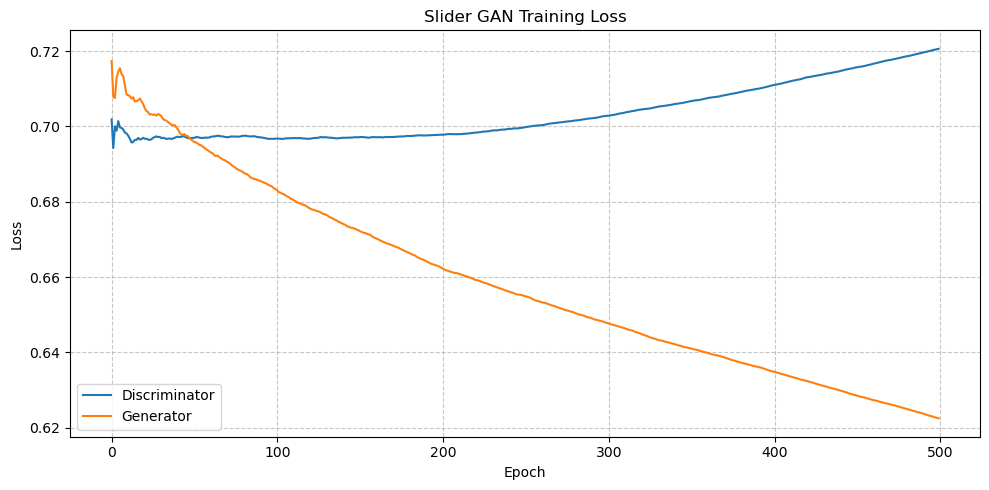

In [9]:
# Set your data directory
data_dir = "C:/Users/julia/DS4440/machine-noise-generator/data"  # Replace with your actual path

# Choose machine type: 'fan', 'pump', 'slider', or 'valve'
machine_type = "slider"  # Change to your desired machine type

# Optionally set specific training parameters (or leave to use defaults)
epochs = 500  # Reduced from 2000 for faster testing
batch_size = 8
samples_per_id = 30

# Run the training
generator, discriminator, losses = run_gan_training(
    machine_type=machine_type,
    data_dir=data_dir,
    epochs=epochs,
    batch_size=batch_size,
    samples_per_id=samples_per_id
)

'''
# After training, you can analyze the audio characteristics
if generator is not None:
    output_dir = f"generated_samples_{machine_type}"
    analyze_audio_characteristics(generator, machine_type, output_dir)

'''